# 3.1. GIẢI THUẬT K-MEANS 

## 3.1.2. Bài tập mẫu 


### Bài toán 1: Thực hiện các nhiệm vụ trong bài toán 1 để làm quen với việc xây dựng mô hình dựa vào thuật toán phân cụm K-Means trên tập dữ liệu Mall-Customer.

#### Nhiệm vụ 1: Thực hiện giải thuật K-Means để phân cụm dữ liệu khách.

In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore') 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
 
df = pd.read_csv('Mall_Customers.csv') 
df['Gender'] = df['Gender'].map({'Male': 1, "Female": 0}) 
df.info() 
X = df.iloc[:, -4:]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [10]:
# We will create K-Means Models `iteratively between k values of 3 to 10` 
# and at each step, capture the `Silhoutte Score` and `Inertia (Sum of 
# Squared Distances)` 
km_inertias, km_scores = [], [] 
for k in range(3, 10): 
    km = KMeans(n_clusters=k).fit(X) 
    km_inertias.append(km.inertia_) 
    km_scores.append(silhouette_score(X, km.labels_)) 
    print(f"Processing K-Means with k = {k}, Intertia = {km.inertia_},  Silhoutte Score = {silhouette_score(X, km.labels_)}") 
km_inertias 


Processing K-Means with k = 3, Intertia = 157219.1737310309,  Silhoutte Score = 0.3117583228805725
Processing K-Means with k = 4, Intertia = 105299.98742210324,  Silhoutte Score = 0.3921703094115865
Processing K-Means with k = 5, Intertia = 75399.61541401484,  Silhoutte Score = 0.4440669204743008
Processing K-Means with k = 6, Intertia = 58387.211042939205,  Silhoutte Score = 0.4506609653808789
Processing K-Means with k = 7, Intertia = 64939.16322344321,  Silhoutte Score = 0.3884446784965776
Processing K-Means with k = 8, Intertia = 48386.82723513046,  Silhoutte Score = 0.39279667409565244
Processing K-Means with k = 9, Intertia = 43719.1928652414,  Silhoutte Score = 0.38597392530877117


[157219.1737310309,
 105299.98742210324,
 75399.61541401484,
 58387.211042939205,
 64939.16322344321,
 48386.82723513046,
 43719.1928652414]

In [11]:
# We will create K-Means Models `iteratively between k values of 3 to 10` 
# and at each step, capture the `Silhoutte Score` and `Inertia (Sum of 
# Squared Distances)` 
km_inertias, km_scores = [], [] 
for k in range(3, 10): 
    km = KMeans(n_clusters=k).fit(X) 
    km_inertias.append(km.inertia_) 
    km_scores.append(silhouette_score(X, km.labels_)) 
    print(f"Processing K-Means with k = {k}, Intertia = {km.inertia_},  Silhoutte Score = {silhouette_score(X, km.labels_)}") 
km_inertias 


Processing K-Means with k = 3, Intertia = 158567.48561601003,  Silhoutte Score = 0.32193440570723825
Processing K-Means with k = 4, Intertia = 105299.98742210324,  Silhoutte Score = 0.3921703094115865
Processing K-Means with k = 5, Intertia = 75427.71182424153,  Silhoutte Score = 0.44424291275274114
Processing K-Means with k = 6, Intertia = 58385.19791162608,  Silhoutte Score = 0.4506571000847437
Processing K-Means with k = 7, Intertia = 52698.3155586849,  Silhoutte Score = 0.42524719492154794
Processing K-Means with k = 8, Intertia = 47757.03842187225,  Silhoutte Score = 0.4282133695224511
Processing K-Means with k = 9, Intertia = 42661.97782634033,  Silhoutte Score = 0.39275913634712795


[158567.48561601003,
 105299.98742210324,
 75427.71182424153,
 58385.19791162608,
 52698.3155586849,
 47757.03842187225,
 42661.97782634033]

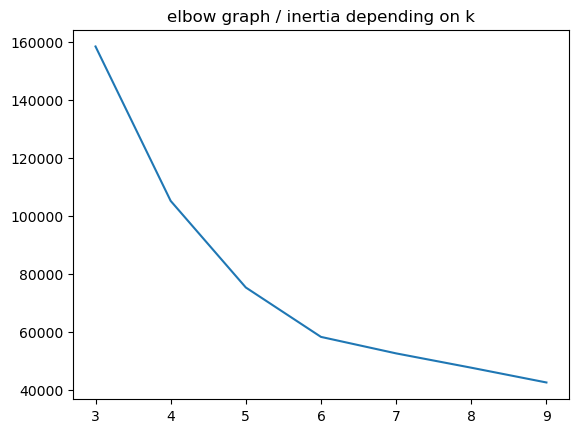

In [12]:
# sns.lineplot(range(3, 10), km_inertias) PHUOCNT 
sns.lineplot(x=range(3, 10), y=km_inertias) 
plt.title('elbow graph / inertia depending on k') 
plt.show() 


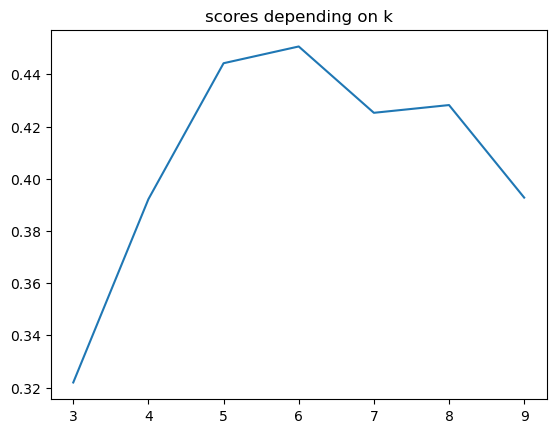

In [13]:
sns.lineplot(x=range(3, 10), y=km_scores) 
plt.title('scores depending on k') 
plt.show() 


In [14]:
km = KMeans(n_clusters=6).fit(X) 
#Assign the Cluster Labels to the Data 
X['Label'] = km.labels_ 
#Info for each cluster 
for k in range(6): 
    print(f'Cluster nb : {k}') 
    print(X[X.Label == k].describe().iloc[:, 1:-1]) 
    print('\n\n') 


Cluster nb : 0
             Age  Annual Income (k$)  Spending Score (1-100)
count  23.000000           23.000000               23.000000
mean   25.521739           26.304348               78.565217
std     5.273170            7.893811               10.953729
min    18.000000           15.000000               61.000000
25%    21.500000           19.500000               73.000000
50%    24.000000           25.000000               77.000000
75%    30.000000           33.000000               84.500000
max    35.000000           39.000000               99.000000



Cluster nb : 1
             Age  Annual Income (k$)  Spending Score (1-100)
count  34.000000           34.000000               34.000000
mean   41.647059           88.735294               16.764706
std    11.058748           16.332360                9.881292
min    19.000000           71.000000                1.000000
25%    34.500000           78.000000               10.000000
50%    42.500000           85.500000               1

### Bài toán 2: Thực hiện phân cụm dữ liệu trên tập dữ liệu iris-data. Dữ liệu lấy từ lấy từ 


#### Nhiệm vụ 1: Phân cụm dữ liệu trên tập dữ liệu iris-data.  


In [17]:


import os, sys, shutil, zipfile, json
from pathlib import Path

DATASET = "uciml/iris"  
DATA_DIR = Path("data_iris")
TARGET = Path("Iris.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

# Đặt biến môi trường Kaggle
os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"

# Kiểm tra kaggle.json tồn tại
config_path = Path(os.environ["KAGGLE_CONFIG_DIR"]) / "kaggle.json"
if not config_path.exists():
    raise FileNotFoundError("⚠️ Không tìm thấy kaggle.json tại C:\\Users\\Admin\\.kaggle\\kaggle.json")

# Xác thực API
api = KaggleApi()
api.authenticate()

# Nếu đã có file thì bỏ qua
if TARGET.exists():
    print(" Đã có Iris.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(" Đang tải dataset từ Kaggle...")
    api.dataset_download_files(dataset=DATASET, path=str(DATA_DIR), unzip=True)
    print(" Giải nén hoàn tất!")

    # Tìm file CSV thực tế trong thư mục data_mall
    csv_files = [f for f in DATA_DIR.glob("*.csv")]
    if not csv_files:
        raise FileNotFoundError("❌ Không tìm thấy file .csv trong thư mục data_mall sau khi tải.")
    else:
        src = csv_files[0]
        shutil.copy2(src, TARGET)
        print(f" Đã tạo {TARGET.name} từ {src.name}")


 Đã có Iris.csv — bỏ qua tải.


In [19]:
%pip install plotly


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.8 MB 9.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.8 MB 13.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.8 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 4.6 MB/s  0:00:02

   ---------------------------------------- 0/2 [narwhals]
   ----------------------------------

In [20]:
import numpy as np 
import pandas as pd 
import plotly.express as px 
import seaborn as sns 
import plotly.graph_objects as go 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.cluster import KMeans 

iris = pd.read_csv("Iris.csv") 
iris.drop('Id', inplace=True, axis=1) 
iris.head().style.background_gradient(cmap=sns.cubehelix_palette(as_cmap=True)) 

X = iris.iloc[:, :-1].values 
y = iris.iloc[:, -1].values


In [24]:
sse = []
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, max_iter=300)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

fig = px.line(y=sse, template="seaborn", title='Elbow Method')
fig.update_layout(width=800, height=600,
                  title_font_color="#BF40BF",
                  xaxis=dict(color="#BF40BF", title="Clusters"),
                  yaxis=dict(color="#BF40BF", title="SSE"))
fig.show()


In [22]:
kmeans = KMeans(n_clusters=3, init='k-means++',
                max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(X)


In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[clusters == 0, 0], y=X[clusters == 0, 1],
    mode='markers', marker_color='#DB4CB2', name='Iris-setosa'))
fig.add_trace(go.Scatter(
    x=X[clusters == 1, 0], y=X[clusters == 1, 1],
    mode='markers', marker_color='#c9e9f6', name='Iris-versicolour'))
fig.add_trace(go.Scatter(
    x=X[clusters == 2, 0], y=X[clusters == 2, 1],
    mode='markers', marker_color='#7D3AC1', name='Iris-virginica'))
fig.add_trace(go.Scatter(
    x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1],
    mode='markers', marker_color='#CAC9CD', marker_symbol=4,
    marker_size=13, name='Centroids'))
fig.update_layout(template='plotly_dark', width=1000,
                  height=500, title='KMeans Clustering Results')
fig.show()


## 3.1.3. Bài tập thực hành 1 Xây dựng mô hình phân cụm K-means trên tập dữ liệu chim cánh cụt. 


In [25]:
import os, sys, shutil, zipfile
from pathlib import Path
import pandas as pd

DATASET = "parulpandey/palmer-archipelago-antarctica-penguin-data"
DATA_DIR = Path("data_penguins")
TARGET = Path("penguins.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"

api = KaggleApi()
api.authenticate()

if TARGET.exists():
    print("✅ Đã có penguins.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print("⏬ Đang tải dữ liệu Penguins từ Kaggle...")
    api.dataset_download_files(DATASET, path=str(DATA_DIR), unzip=True)
    print("✅ Giải nén hoàn tất!")
    csv_files = [f for f in DATA_DIR.glob("*.csv")]
    src = csv_files[0]
    shutil.copy2(src, TARGET)
    print(f"✅ Đã tạo {TARGET.name} từ {src.name}")

data = pd.read_csv(TARGET)
data.head()


⏬ Đang tải dữ liệu Penguins từ Kaggle...
Dataset URL: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data
✅ Giải nén hoàn tất!
✅ Đã tạo penguins.csv từ penguins_lter.csv


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Hiển thị thông tin dữ liệu
data.info()
data.describe(include='all')

# Loại bỏ hàng có giá trị null
data = data.dropna()

# Mã hóa các cột dạng chuỗi thành số
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col])

# Lấy đặc trưng để phân cụm (loại trừ cột species nếu có)
if 'species' in data.columns:
    X = data.drop(columns=['species'])
else:
    X = data.copy()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

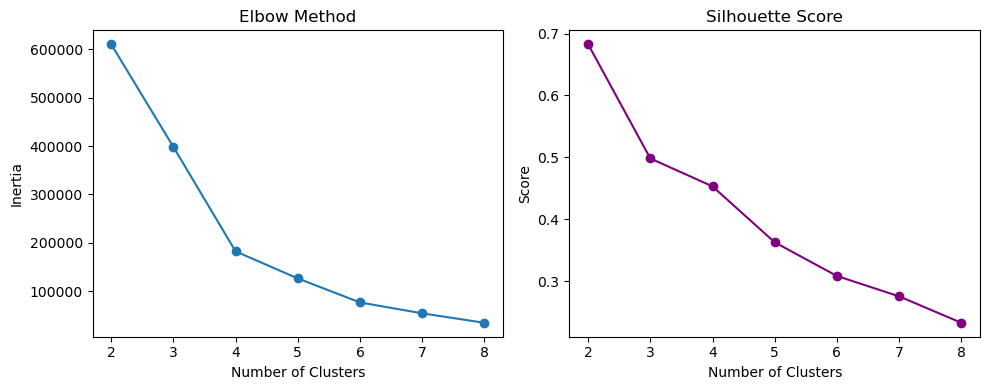

In [27]:
inertia, scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=24).fit(X)
    inertia.append(km.inertia_)
    scores.append(silhouette_score(X, km.labels_))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(2,9), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(range(2,9), scores, marker='o', color='purple')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


In [28]:
kmeans = KMeans(n_clusters=3, init='k-means++',
                max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)

data['Cluster'] = clusters
data.head()


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,Cluster
6,0,7,0,0,2,0,5,0,3,38.9,17.8,181.0,3625.0,0,9.18718,-25.21799,0,2
7,0,8,0,0,2,0,6,0,3,39.2,19.6,195.0,4675.0,1,9.46060,-24.89958,0,1
28,0,29,0,0,0,0,0,0,0,37.9,18.6,172.0,3150.0,0,8.38404,-25.19837,0,0
29,0,30,0,0,0,0,1,0,0,40.5,18.9,180.0,3950.0,1,8.90027,-25.11609,0,2
38,0,39,0,0,1,0,2,0,2,37.6,19.3,181.0,3300.0,0,9.41131,-25.04169,0,0


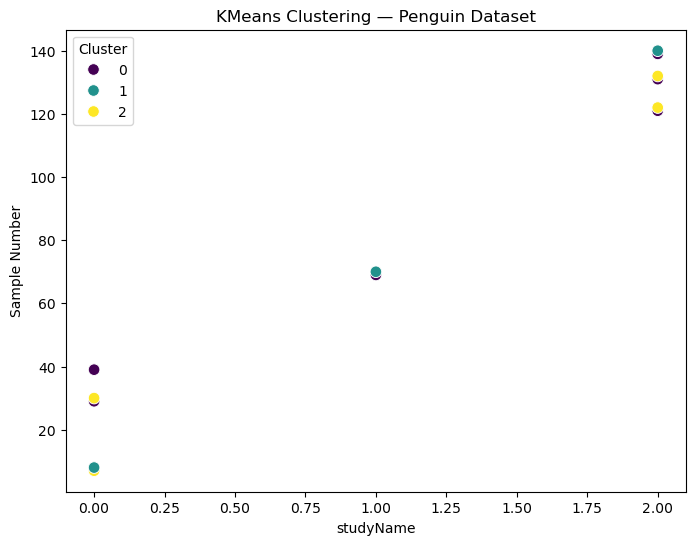

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data.iloc[:,0], y=data.iloc[:,1],
                hue=data['Cluster'], palette='viridis', s=70)
plt.title("KMeans Clustering — Penguin Dataset")
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.legend(title='Cluster')
plt.show()


In [30]:
print("Silhouette Score:", silhouette_score(X, clusters))
print("\nSố lượng mẫu trong từng cụm:")
print(data['Cluster'].value_counts())

print("\nTrung bình các đặc trưng theo cụm:")
print(data.groupby('Cluster').mean())


Silhouette Score: 0.4692821623705801

Số lượng mẫu trong từng cụm:
Cluster
0    6
2    4
1    3
Name: count, dtype: int64

Trung bình các đặc trưng theo cụm:
         studyName  Sample Number  Species  Region    Island  Stage  \
Cluster                                                               
0         1.166667      88.000000      0.0     0.0  1.333333    0.0   
1         1.000000      72.666667      0.0     0.0  1.666667    0.0   
2         1.000000      72.750000      0.0     0.0  1.500000    0.0   

         Individual ID  Clutch Completion  Date Egg  Culmen Length (mm)  \
Cluster                                                                   
0             5.333333                0.0  3.000000           37.183333   
1             7.333333                0.0  2.666667           40.233333   
2             6.000000                0.0  3.500000           40.050000   

         Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)   Sex  \
Cluster                               

##  3.1.4. Bài tập thực hành 2 Xây dựng mô hình phân cụm K-means trên tập dữ liệu mua sắm tại siêu thị. Dữ liệu lấy tại 


In [ ]:
import os, sys, shutil, zipfile
from pathlib import Path
import pandas as pd

DATASET = "hellbuoy/online-retail-customer-clustering"
DATA_DIR = Path("data_retail")
TARGET = Path("OnlineRetail.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"
api = KaggleApi()
api.authenticate()

if TARGET.exists():
    print(" Đã có OnlineRetail.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(" Đang tải dataset Online Retail từ Kaggle...")
    api.dataset_download_files(dataset=DATASET, path=str(DATA_DIR), unzip=True)
    print(" Giải nén hoàn tất!")
    csv_files = [f for f in DATA_DIR.glob("*.csv")]
    if not csv_files:
        raise FileNotFoundError(" Không tìm thấy file CSV sau khi tải.")
    src = csv_files[0]
    shutil.copy2(src, TARGET)
    print(f" Đã tạo {TARGET.name} từ {src.name}")

data = pd.read_csv(TARGET, encoding='unicode_escape')
data.head()


⏬ Đang tải dataset Online Retail từ Kaggle...
Dataset URL: https://www.kaggle.com/datasets/hellbuoy/online-retail-customer-clustering
✅ Giải nén hoàn tất!
✅ Đã tạo OnlineRetail.csv từ OnlineRetail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Parse kiểu thời gian + lọc dữ liệu hợp lệ
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], errors='coerce')
data = data.dropna(subset=['CustomerID','InvoiceDate','Quantity','UnitPrice'])

# Tạo TotalPrice nếu chưa có
if 'TotalPrice' not in data.columns:
    data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

# (Tuỳ chọn) bỏ các dòng trả hàng/giá trị âm
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0) & (data['TotalPrice'] > 0)]

# Tính RFM
max_date = data['InvoiceDate'].max()
rfm = data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Chuẩn hoá đặc trưng
scaler = StandardScaler()
X = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])


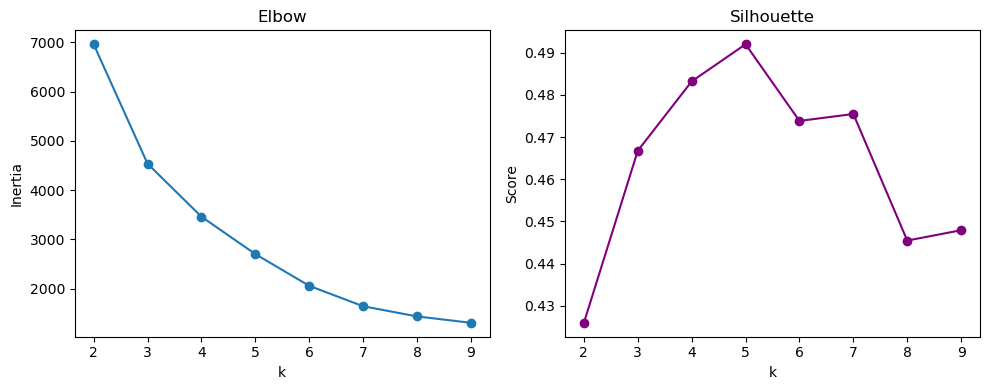

In [35]:
inertia, sil_scores = [], []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(range(2,10), inertia, marker='o'); plt.title("Elbow"); plt.xlabel("k"); plt.ylabel("Inertia")
plt.subplot(1,2,2); plt.plot(range(2,10), sil_scores, marker='o', color='purple'); plt.title("Silhouette"); plt.xlabel("k"); plt.ylabel("Score")
plt.tight_layout(); plt.show()


In [36]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12347.0,95,5,2540.29,0
1,12348.0,220,1,367.00,1
2,12350.0,311,1,334.40,1
3,12352.0,274,3,1296.38,1
4,12355.0,96,1,459.40,0


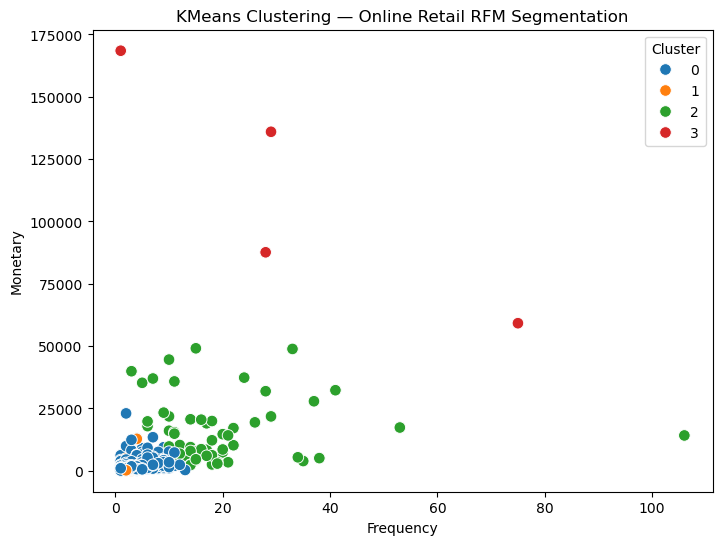

In [37]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='tab10', s=70)
plt.title("KMeans Clustering — Online Retail RFM Segmentation")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title='Cluster')
plt.show()


# 3.2. GIẢI THUẬT PHÂN CỤM ĐA CẤP

## 3.2.2. Bài làm mẫu 


### Bài toán 1: Tìm hiểu một số khái niệm cơ bản của phân cụm đa cấp 


#### Nhiệm vụ 1: Tìm hiểu một số khái niệm cơ bản của phân cụm đa cấp 


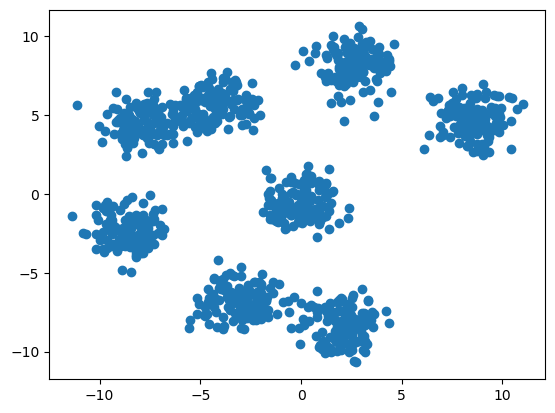

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster 
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt 
%matplotlib inline 

# Generate a random cluster dataset to experiment on
X, y = make_blobs(n_samples=1000, centers=8, n_features=2, random_state=800)
plt.scatter(X[:,0], X[:,1])
plt.show()


In [39]:
# Generate distance matrix with 'linkage' function 
distances = linkage(X, method="centroid", metric="euclidean") 
print(distances)


[[5.72000000e+02 7.62000000e+02 7.69412624e-03 2.00000000e+00]
 [3.00000000e+01 1.96000000e+02 8.87881891e-03 2.00000000e+00]
 [5.91000000e+02 8.70000000e+02 1.07476240e-02 2.00000000e+00]
 ...
 [1.98900000e+03 1.99200000e+03 7.81168528e+00 3.75000000e+02]
 [1.99500000e+03 1.99600000e+03 1.02408477e+01 7.50000000e+02]
 [1.99400000e+03 1.99700000e+03 1.20025814e+01 1.00000000e+03]]


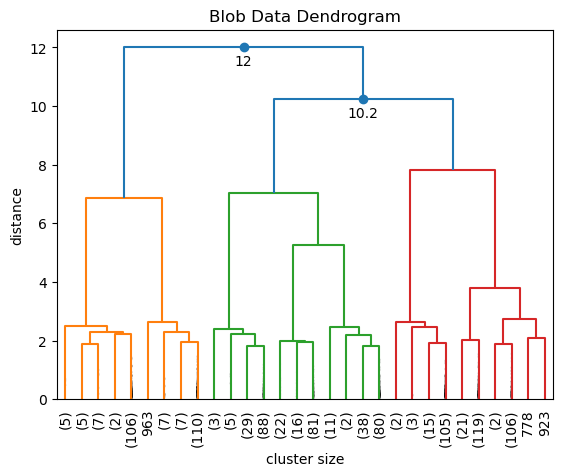

In [40]:
# Take normal dendrogram output and stylize in cleaner way 
def annotated_dendrogram(*args, **kwargs): 
    scipy_dendro = dendrogram(*args, truncate_mode='lastp',  
                              show_contracted=True, leaf_rotation=90.) 
    plt.title('Blob Data Dendrogram') 
    plt.xlabel('cluster size') 
    plt.ylabel('distance') 
    for i, d, c in zip(scipy_dendro['icoord'], scipy_dendro['dcoord'],  
                       scipy_dendro['color_list']): 
        x = 0.5 * sum(i[1:3]) 
        y = d[1] 
        if y > 10: 
            plt.plot(x, y, 'o', c=c) 
            plt.annotate("%.3g" % y, (x, y), xytext=(0, -5), 
                         textcoords='offset points', 
                         va='top', ha='center') 
    return scipy_dendro 

dn = annotated_dendrogram(distances) 
plt.show()


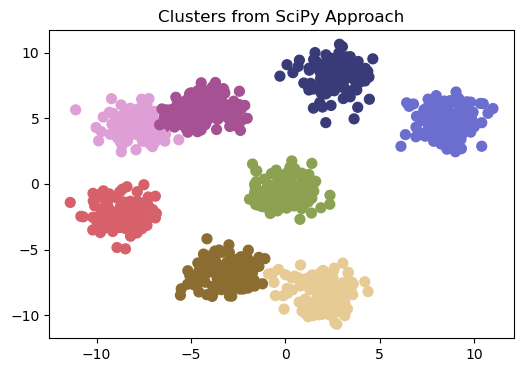

In [41]:
scipy_clusters = fcluster(distances, 3, criterion="distance") 
plt.figure(figsize=(6,4)) 
plt.title("Clusters from SciPy Approach") 
plt.scatter(X[:, 0], X[:, 1], c=scipy_clusters, s=50, cmap='tab20b') 
plt.show()


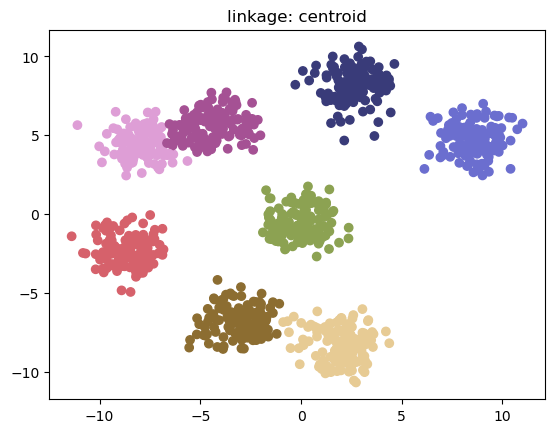

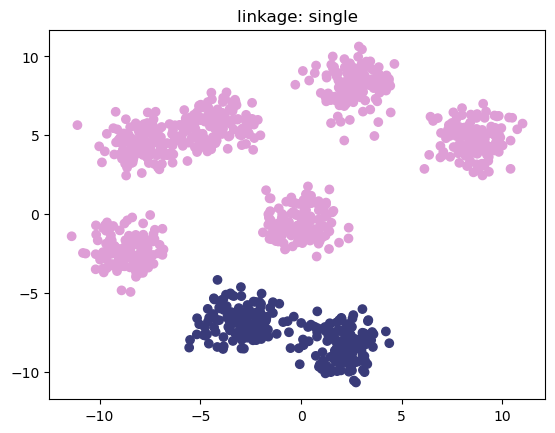

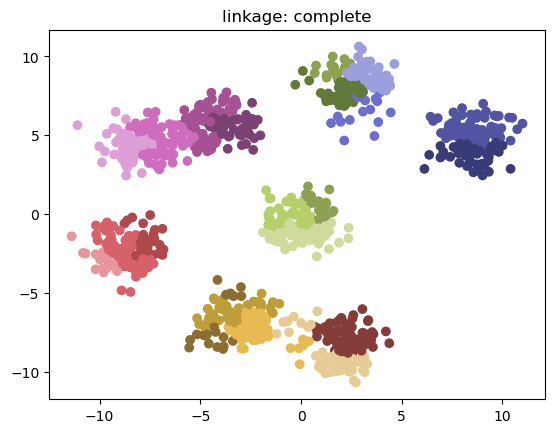

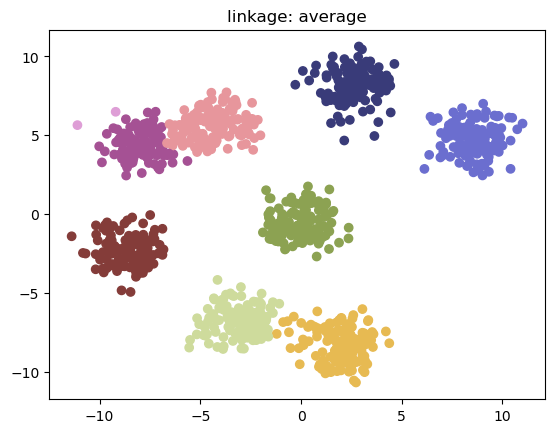

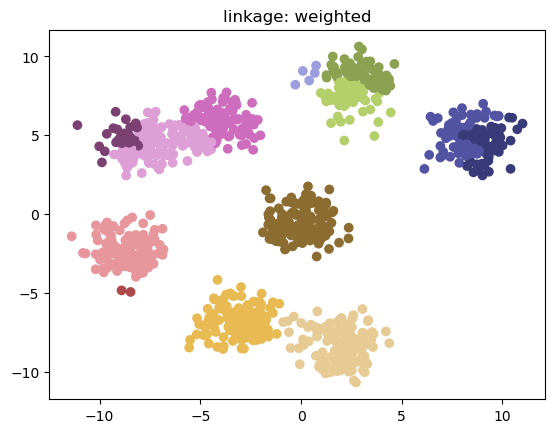

In [42]:
methods = ['centroid', 'single', 'complete', 'average', 'weighted'] 
for method in methods: 
    distances = linkage(X, method=method, metric="euclidean") 
    clusters = fcluster(distances, 3, criterion="distance")  
    plt.title('linkage: ' + method) 
    plt.scatter(X[:,0], X[:,1], c=clusters, cmap='tab20b') 
    plt.show()


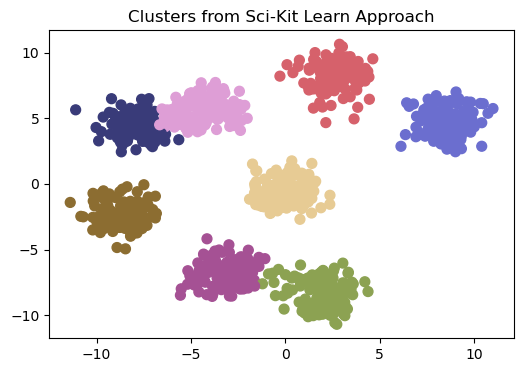

In [43]:
from sklearn.cluster import AgglomerativeClustering 
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster 

ac = AgglomerativeClustering(n_clusters=8, linkage="average") 
sklearn_clusters = ac.fit_predict(X) 
scipy_clusters = fcluster(distances, 3, criterion="distance") 

plt.figure(figsize=(6,4)) 
plt.title("Clusters from Sci-Kit Learn Approach") 
plt.scatter(X[:, 0], X[:, 1], c=sklearn_clusters, s=50, cmap='tab20b') 
plt.show()


### Bài toán 2: Phân cụm đa cấp trên tập dữ liệu rượu vang. 


In [ ]:
import os, sys, shutil, zipfile
from pathlib import Path
import pandas as pd

DATASET = "harrywang/wine-dataset-for-clustering"
DATA_DIR = Path("data_wine")
TARGET = Path("wine_data.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"

api = KaggleApi()
api.authenticate()

if TARGET.exists():
    print(" Đã có wine_data.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(" Đang tải dữ liệu wine...")
    api.dataset_download_files(DATASET, path=str(DATA_DIR), unzip=True)
    print(" Giải nén hoàn tất!")
    csv_files = [f for f in DATA_DIR.glob("*.csv")]
    src = csv_files[0]
    shutil.copy2(src, TARGET)
    print(f" Đã tạo {TARGET.name} từ {src.name}")

wine_df = pd.read_csv(TARGET)
wine_df.head()


⏬ Đang tải dữ liệu wine...
Dataset URL: https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering
✅ Giải nén hoàn tất!
✅ Đã tạo wine_data.csv từ wine-clustering.csv


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


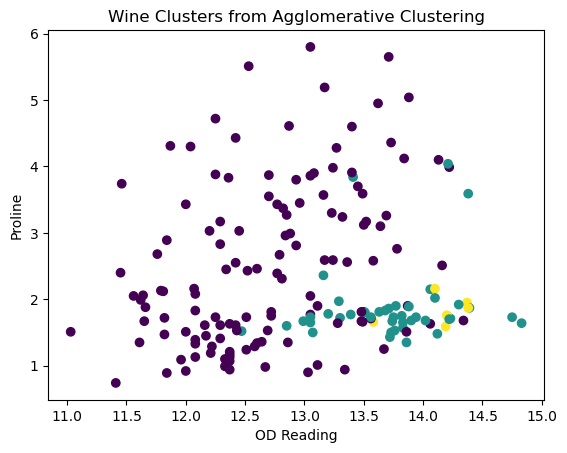

In [45]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

ac = AgglomerativeClustering(3, linkage='average')
ac_clusters = ac.fit_predict(wine_df)

plt.scatter(wine_df.values[:,0], wine_df.values[:,1], c=ac_clusters)
plt.title("Wine Clusters from Agglomerative Clustering")
plt.xlabel("OD Reading")
plt.ylabel("Proline")
plt.show()


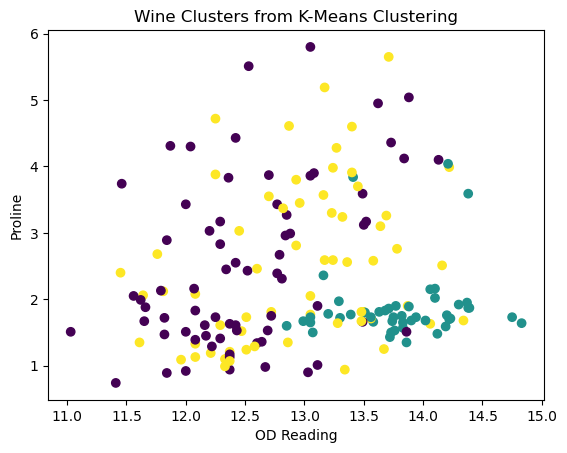

In [46]:
from sklearn.cluster import KMeans

km = KMeans(3)
km_clusters = km.fit_predict(wine_df)

plt.scatter(wine_df.values[:,0], wine_df.values[:,1], c=km_clusters)
plt.title("Wine Clusters from K-Means Clustering")
plt.xlabel("OD Reading")
plt.ylabel("Proline")
plt.show()


In [47]:
from sklearn.metrics import silhouette_score

print("Silhouette Scores for Wine Dataset:\n")
print("K-Means Clustering: ", silhouette_score(wine_df, km_clusters))
print("Agg Clustering: ", silhouette_score(wine_df, ac_clusters))


Silhouette Scores for Wine Dataset:

K-Means Clustering:  0.571138193786884
Agg Clustering:  0.6100753288756409


## 3.2.3. Bài tập thực hành 1 Xây dựng mô hình phân cụm đa cấp trên tập dữ liệu chim cánh cụt. 


In [ ]:
import os, sys, shutil, zipfile
from pathlib import Path
import pandas as pd

DATASET = "parulpandey/palmer-archipelago-antarctica-penguin-data"
DATA_DIR = Path("data_penguins_hc")
TARGET = Path("penguins.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"
api = KaggleApi(); api.authenticate()

if TARGET.exists():
    print(" Đã có penguins.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(" Đang tải dữ liệu Penguins…")
    api.dataset_download_files(DATASET, path=str(DATA_DIR), unzip=True)
    print(" Giải nén hoàn tất!")
    src = next(p for p in DATA_DIR.glob("*.csv"))
    shutil.copy2(src, TARGET)
    print(f" Đã tạo {TARGET.name} từ {src.name}")

df = pd.read_csv(TARGET)
df.head()


✅ Đã có penguins.csv — bỏ qua tải.


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
df.columns = [c.strip().lower().replace(' ', '_').replace('(', '').replace(')', '') for c in df.columns]
print("Tên cột hiện có:", list(df.columns))
cols_num = [c for c in df.columns if any(k in c for k in ['culmen', 'flipper', 'body'])]
df = df.dropna(subset=cols_num)
X_raw = df[cols_num].copy()
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

x0, x1 = X[:, 0], X[:, 1]


Tên cột hiện có: ['studyname', 'sample_number', 'species', 'region', 'island', 'stage', 'individual_id', 'clutch_completion', 'date_egg', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'delta_15_n_o/oo', 'delta_13_c_o/oo', 'comments']


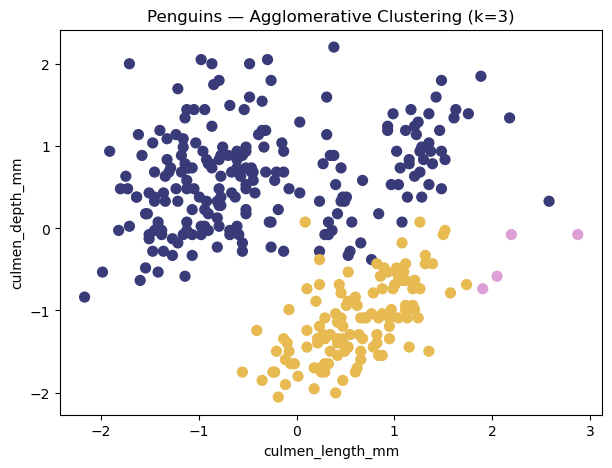

In [52]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(n_clusters=3, linkage='average')
ac_clusters = ac.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(x0, x1, c=ac_clusters, s=50, cmap='tab20b')
plt.title("Penguins — Agglomerative Clustering (k=3)")
plt.xlabel(cols_num[0]); plt.ylabel(cols_num[1])
plt.show()


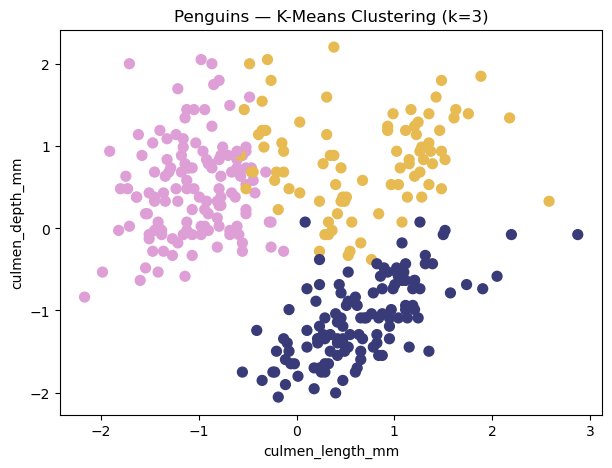

In [53]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=24)
km_clusters = km.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(x0, x1, c=km_clusters, s=50, cmap='tab20b')
plt.title("Penguins — K-Means Clustering (k=3)")
plt.xlabel(cols_num[0]); plt.ylabel(cols_num[1])
plt.show()


In [54]:
print("Silhouette Scores for Penguins:\n")
print("K-Means Clustering: ", round(silhouette_score(X, km_clusters), 4))
print("Agg Clustering:     ", round(silhouette_score(X, ac_clusters), 4))


Silhouette Scores for Penguins:

K-Means Clustering:  0.4472
Agg Clustering:      0.4416


## 3.2.4. Bài tập thực hành 2 Xây dựng mô hình phân cụm đa cấp trên tập dữ liệu mua sắm tại siêu thị.

In [ ]:
import os, sys, shutil, zipfile
from pathlib import Path
import pandas as pd

DATASET = "hellbuoy/online-retail-customer-clustering"
DATA_DIR = Path("data_retail_hc")
TARGET = Path("OnlineRetail.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"

api = KaggleApi()
api.authenticate()

if TARGET.exists():
    print(" Đã có OnlineRetail.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(" Đang tải dữ liệu Online Retail từ Kaggle…")
    api.dataset_download_files(DATASET, path=str(DATA_DIR), unzip=True)
    print(" Giải nén hoàn tất!")
    csv_files = [f for f in DATA_DIR.glob("*.csv")]
    src = csv_files[0]
    shutil.copy2(src, TARGET)
    print(f" Đã tạo {TARGET.name} từ {src.name}")

df = pd.read_csv(TARGET, encoding='unicode_escape')
df.head()


✅ Đã có OnlineRetail.csv — bỏ qua tải.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['CustomerID','InvoiceDate','Quantity','UnitPrice'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
max_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

x0, x1 = X[:, 0], X[:, 1]


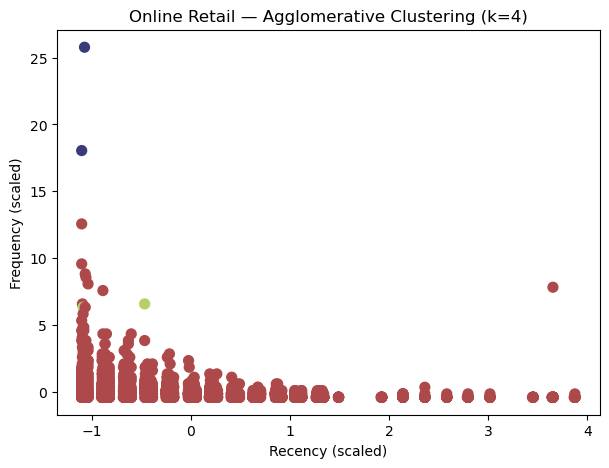

In [57]:
ac = AgglomerativeClustering(n_clusters=4, linkage='average')
ac_clusters = ac.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(x0, x1, c=ac_clusters, s=50, cmap='tab20b')
plt.title("Online Retail — Agglomerative Clustering (k=4)")
plt.xlabel("Recency (scaled)")
plt.ylabel("Frequency (scaled)")
plt.show()


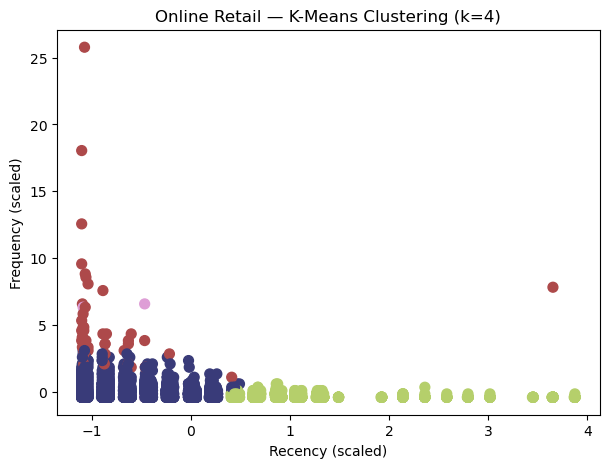

In [58]:
km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
km_clusters = km.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(x0, x1, c=km_clusters, s=50, cmap='tab20b')
plt.title("Online Retail — K-Means Clustering (k=4)")
plt.xlabel("Recency (scaled)")
plt.ylabel("Frequency (scaled)")
plt.show()


In [59]:
print("Silhouette Scores for Online Retail:\n")
print("K-Means Clustering: ", round(silhouette_score(X, km_clusters), 4))
print("Agg Clustering:     ", round(silhouette_score(X, ac_clusters), 4))


Silhouette Scores for Online Retail:

K-Means Clustering:  0.4785
Agg Clustering:      0.9311
